# ****ECOMMERCE SALES ANALYSIS****

# ***DATA lOADING***

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.simplefilter("ignore")

In [2]:
df = pd.read_csv("ecomerece data.csv")
df

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code,Latitude,Longtitude
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0,1.0,0.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0,1.0,0.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0,1.0,0.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0,1.0,0.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0,1.0,0.0
502,18,Headphones,Electronics,14085.56,2,Debit Card,18/01/2023,28171.12,January,0.0,1.0,2.0,1.0,0.0
503,19,Laptop,Accessories,53657.14,4,Debit Card,19/01/2023,214628.56,January,0.1,1.0,2.0,1.0,0.0
504,20,Watch,Fashion,74385.39,4,Credit Card,20/01/2023,297541.56,January,0.0,1.0,2.0,1.0,0.0


# **DATA PREPROCESSING**

In [3]:
df.dtypes

order_id                 int64
product                 object
category                object
price                  float64
quantity                 int64
payment_method          object
date                    object
total                  float64
Month                   object
Discount               float64
City Code              float64
Order Priority Code    float64
Latitude               float64
Longtitude             float64
dtype: object

In [4]:
df.drop(["Latitude","Longtitude"],axis=1,inplace=True)

df


,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
501,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
502,18,Headphones,Electronics,14085.56,2,Debit Card,18/01/2023,28171.12,January,0.0,1.0,2.0
503,19,Laptop,Accessories,53657.14,4,Debit Card,19/01/2023,214628.56,January,0.1,1.0,2.0
504,20,Watch,Fashion,74385.39,4,Credit Card,20/01/2023,297541.56,January,0.0,1.0,2.0


In [5]:
df.rename(columns={'City Code': 'city','Order Priority Code':'Order priorty'}, inplace=True)
df

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,city,Order priorty
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
501,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
502,18,Headphones,Electronics,14085.56,2,Debit Card,18/01/2023,28171.12,January,0.0,1.0,2.0
503,19,Laptop,Accessories,53657.14,4,Debit Card,19/01/2023,214628.56,January,0.1,1.0,2.0
504,20,Watch,Fashion,74385.39,4,Credit Card,20/01/2023,297541.56,January,0.0,1.0,2.0


In [6]:
df.duplicated()


0      False
1      False
2      False
3      False
4      False
       ...  
501     True
502     True
503     True
504     True
505     True
Length: 506, dtype: bool

In [7]:
df=df.drop_duplicates()

In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
df.isnull().sum()

order_id           0
product            0
category           0
price              0
quantity           0
payment_method     0
date               0
total              0
Month              0
Discount           0
city              15
Order priorty     19
dtype: int64

In [10]:


df['city'] = df['city'].fillna(df['city'].median())
df['Order priorty'] = df['Order priorty'].fillna(df['Order priorty'].median())
df.isnull().sum()


order_id          0
product           0
category          0
price             0
quantity          0
payment_method    0
date              0
total             0
Month             0
Discount          0
city              0
Order priorty     0
dtype: int64

In [11]:
priority_map = {
    0: "LOW",
    1: "MEDIUM",
    2: "HIGH",
    3: "CRITICAL"
}
df["Order priorty"] = df["Order priorty"].map(priority_map)
df

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,city,Order priorty
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.00,1.0,HIGH
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.10,1.0,HIGH
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.10,1.0,HIGH
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.10,1.0,HIGH
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.00,1.0,HIGH
...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,Watch,Electronics,66152.43,2,JazzCash,10/05/2024,132304.86,May,0.65,4.0,MEDIUM
496,497,Laptop,Electronics,10745.15,2,Easypaisa,11/05/2024,21490.30,May,0.70,4.0,MEDIUM
497,498,Laptop,Electronics,27141.95,1,JazzCash,12/05/2024,27141.95,May,0.70,4.0,MEDIUM
498,499,Bag,Fashion,59608.91,3,Credit Card,13/05/2024,178826.73,May,0.80,4.0,MEDIUM



# ***Exploratory Data Analysis***



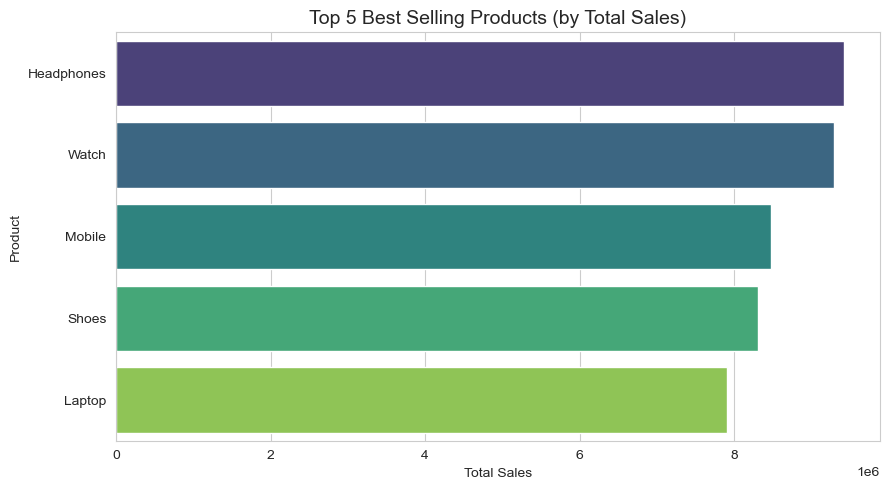

In [12]:
# top 5 best selling product
sns.set_style("whitegrid")
plt.figure(figsize=(9,5))
top_products = df.groupby('product')['total'].sum().sort_values(ascending=False).head(5)
palette = sns.color_palette("viridis", len(top_products))  
sns.barplot(x=top_products.values, y=top_products.index, palette=palette)
plt.title("Top 5 Best Selling Products (by Total Sales)", fontsize=14)
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


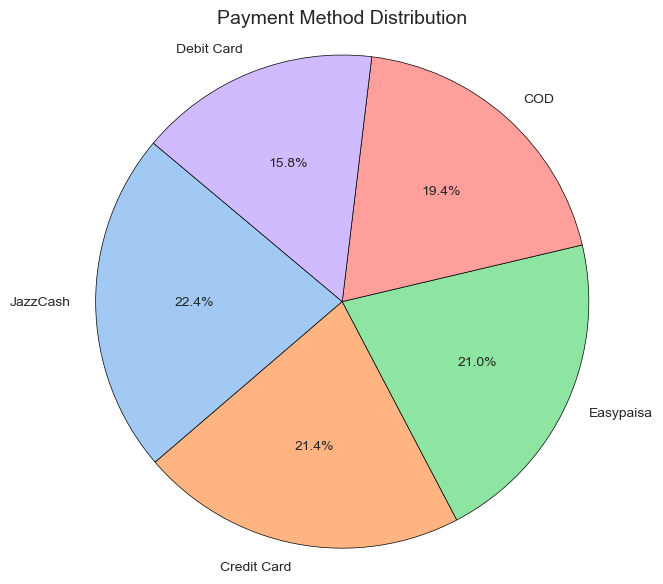

In [13]:
# 2) Payment Method Distribution
plt.figure(figsize=(7,7))
payment_counts = df['payment_method'].value_counts()
colors = sns.color_palette("pastel")[0:len(payment_counts)]
plt.pie(payment_counts, labels=payment_counts.index, autopct='%2.1f%%', startangle=140, colors=colors, wedgeprops={'edgecolor':'k', 'linewidth':0.5})
plt.title("Payment Method Distribution", fontsize=14)
plt.axis('equal')
plt.show()


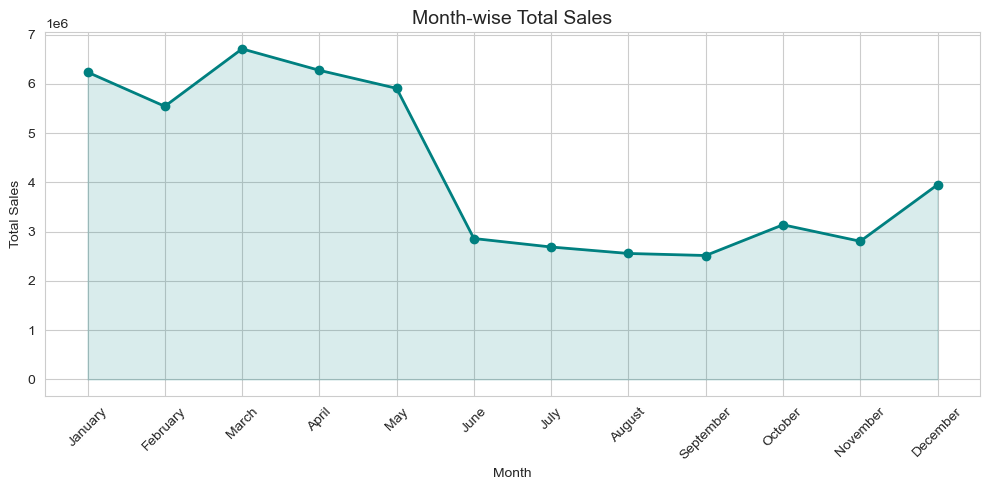

In [14]:


# Define month order
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

# Convert Month column to categorical with order
df["Month"] = pd.Categorical(df["Month"], categories=month_order, ordered=True)

# Group by month and sum total sales
month_sales = df.groupby("Month")["total"].sum().reindex(month_order)  # ensures correct order

# Plot line chart
plt.figure(figsize=(10,5))
plt.plot(month_sales.index, month_sales.values, marker="o", linewidth=2, color="teal")
plt.fill_between(month_sales.index, month_sales.values, alpha=0.15, color="teal")
plt.title("Month-wise Total Sales", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


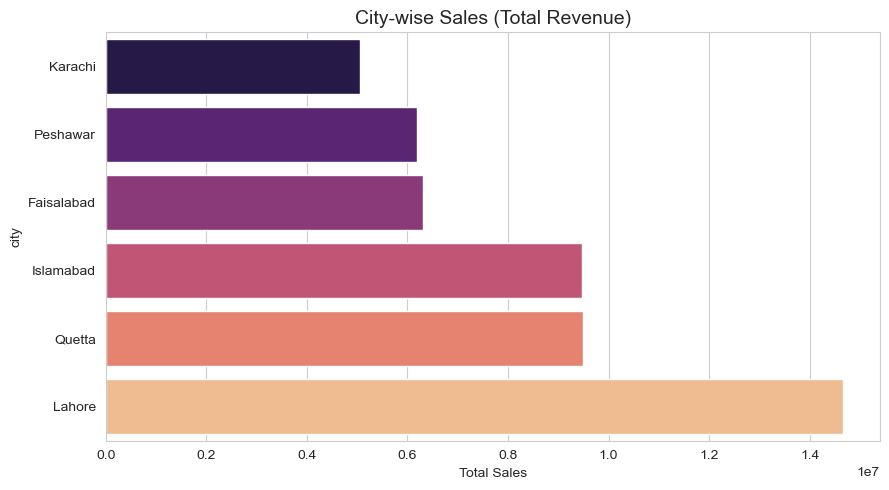

In [16]:


# Map numeric city codes to names
city_map = {
    1: "Karachi",
    2: "Lahore",
    3: "Islamabad",
    4: "Faisalabad",
    5: "Quetta",
    6: "Peshawar"
}

# Replace numeric codes with city names in a new column
df["City Name"] = df["city"].map(city_map)  

# Group by city names and sum total sales
city_sales = df.groupby("City Name")["total"].sum().sort_values()

# Plot horizontal bar chart
plt.figure(figsize=(9,5))
sns.barplot(x=city_sales.values, y=city_sales.index, palette="magma")
plt.title("City-wise Sales (Total Revenue)", fontsize=14)
plt.xlabel("Total Sales")
plt.ylabel("city")
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

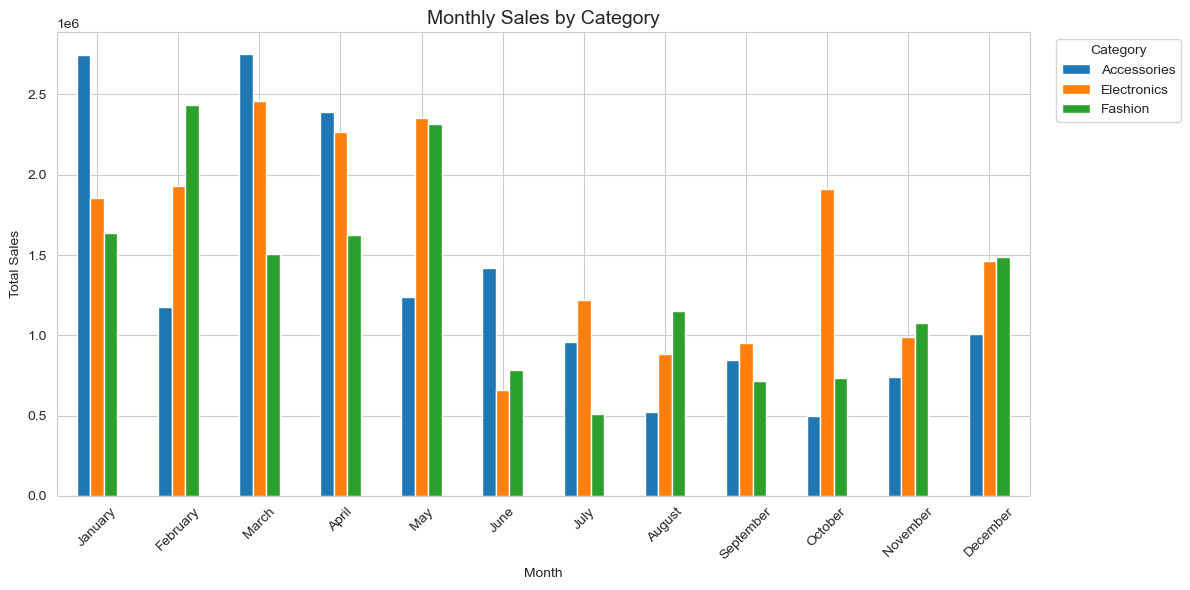

In [17]:
monthly_category = (
    df.groupby(["Month", "category"])["total"]
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12,6))
monthly_category.plot(kind="bar", figsize=(12,6))
plt.title("Monthly Sales by Category", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# **OBSERVATIONS**

## 1. Products and Revenue

### Headphones are clearly the star performer, followed closely by watches. These two alone are driving the majority of revenue. Laptops, while important, lag behind, indicating that customers value practical electronics and daily-use gadgets over expensive items right now. Mobile phones and shoes hold steady, showing consistent demand, but the real growth lies in leveraging top performers. This tells us that the business should focus on keeping these high-demand products always in stock and highlight them in campaigns to attract more buyers.

## 2. Payment Preferences

### Most customers use JazzCash, Credit Card, or Easypaisa. This is more than just numbers it reflects trust and convenience. By making these payment options smooth and hassle-free, the company can reduce abandoned carts, improve conversion rates, and build loyalty. COD and Debit Card are used less, which means either marketing or incentives could increase their usage if desired, but the focus should remain on the preferred methods.

## 3. Monthly Sales Trends

### Revenue peaks in January and March, likely due to seasonal demand or promotional campaigns. The summer months, July to September, show a noticeable drop. This isn’t a problem it’s an opportunity. Strategic campaigns, flash sales, or bundle offers during slow months can balance revenue, keeping cash flow steady throughout the year. The data shows the business has predictable cycles, which is a big advantage for planning inventory and marketing.

## 4. City Performance

### Lahore dominates revenue, followed by Quetta, Islamabad, Faisalabad, Peshawar, and Karachi. This isn’t just geography; it’s insight into where the customer base is strongest and where marketing and logistics should be concentrated. High-revenue cities should get priority in inventory allocation and delivery speed. Smaller cities are untapped potential targeted local promotions and better delivery options could turn them into significant revenue contributors.

## 5. Category Insights

### Electronics are the backbone of sales, providing stable and high revenue. Fashion and accessories are smaller but consistent contributors. This mix allows the business to experiment with seasonal promotions and category bundling. Knowing which categories dominate allows smarter marketing investment, inventory planning, and product development.

# **Conclusion** 

### The business is thriving on a few core products and cities. Headphones and Watches are the true revenue engines, with Electronics forming a stable backbone. Revenue peaks in January and March, while summer months provide an opportunity for targeted growth. Lahore, Quetta, and Islamabad are top markets, but smaller cities show potential if approached correctly. Customers prefer certain payment methods, and understanding these preferences can increase sales efficiency. By combining these insights, the company can make smarter decisions about inventory, promotions, city strategies, and customer experience, resulting in higher profitability and sustainable growth.

# **Recommendations**

## Product Strategy

### Always stock high demand items like Headphones and Watches.

### Consider bundle offers with Accessories or Fashion to increase average order value.

### Use the data to predict demand for Mobile phones and Shoes and avoid overstocking low-demand items like Laptops.

## Marketing Strategy

### Run targeted campaigns in slow months (July–September) to balance revenue.

### Highlight top products in social media and email campaigns to attract new buyers.

### Experiment with city-specific promotions in smaller markets to unlock new revenue streams.

## City & Logistics Strategy

### Prioritize Lahore and other high-performing cities for fast delivery and premium service.

### For smaller cities, introduce cost-effective delivery options and localized campaigns.

## Payment Experience

### Make JazzCash, Credit Card, and Easypaisa checkout seamless.

### Encourage repeat purchases by offering small discounts or rewards on preferred payment methods.

## Data-Driven Planning

### Use historical trends to forecast inventory and marketing budget.

### Prepare stock for peak months while running creative campaigns in low months.

### Monitor city wise growth to adjust marketing, pricing, and logistics dynamically.

### The business grows by focusing on what truly matters high-demand products, key cities, and trusted payment methods. Seasonal dips are not a weakness; they are opportunities for smart marketing and inventory planning. By understanding customer preferences and city dynamics, the business can allocate resources where they create maximum impact, increase revenue without extra cost, and build a loyal customer base. This is how a smart business thinks not just about what sells, but why it sells and where the next growth comes from.